# Badanie Efektywności Reprezentacji Ortogonalnej Sygnałów 1D

---


## 1. Założenia Badawcze (Metoda Monte Carlo)
W tej części projektu odchodzimy od statycznego progu kompresji na rzecz badania **kosztu reprezentacji** sygnału. 
* **Próba:** Przeprowadzamy testy na $N=100$ niezależnych realizacjach dla każdej z 3 klas sygnałów (**APRBS**, **Multisine**, **Filtered Noise**).
* **Cel:** Wyznaczenie współczynnika $K$ – minimalnej liczby współczynników ortogonalnych niezbędnych do odtworzenia sygnału z zachowaniem **95% jego całkowitej energii**.
* **Hipoteza:** Wartość $K$ będzie zmienną losową zależną od charakterystyki sygnału. Spodziewamy się najniższych średnich wartości dla klasy *Multisine* (sygnały rzadkie w dziedzinie częstotliwości) i najwyższych dla *APRBS* (sygnały szerokopasmowe).



---

## 2. Podstawy Teoretyczne

### 2.1. Transformata Fouriera (Analiza)
Dyskretna Transformata Fouriera (DFT) pozwala na dekompozycję sygnału z dziedziny czasu na sumę ortogonalnych funkcji bazowych (zespolonych wykładniczych/sinusoidalnych).



Wzór na współczynniki widmowe:
$$X[k] = \sum_{n=0}^{N-1} x[n] \cdot e^{-j \frac{2\pi}{N} kn}$$

Każdy współczynnik $X[k]$ reprezentuje amplitudę i fazę składowej o konkretnej częstotliwości.


### 2.2. Odwrotna Transformata Fouriera (Synteza)
Proces odwrotny pozwala na rekonstrukcję sygnału czasowego. W procesie kompresji, część współczynników $X[k]$ (te o najmniejszej energii) jest zerowana, co prowadzi do przybliżonej rekonstrukcji:

$$\hat{x}[n] = \frac{1}{N} \sum_{k=0}^{N-1} \hat{X}[k] \cdot e^{j \frac{2\pi}{N} kn}$$

### 2.3. Mierzenie Energii i Twierdzenie Parsevala
Energia sygnału jest miarą jego zawartości informacyjnej. Zgodnie z **Twierdzeniem Parsevala**, całkowita energia w dziedzinie czasu odpowiada energii w dziedzinie częstotliwości:

$$E_{total} = \sum_{n=0}^{N-1} |x[n]|^2 = \frac{1}{N} \sum_{k=0}^{N-1} |X[k]|^2$$

---

## 3. Metodyka Wyznaczania Współczynnika $K$
Aby wyznaczyć współczynnik $K$ dla progu 95%, stosujemy następującą procedurę:
1. **Obliczenie mocy:** Wyznaczamy moc poszczególnych składowych: $P[k] = |X[k]|^2$.
2. **Sortowanie:** Sortujemy moce $P[k]$ malejąco: $P_{sorted}$.
3. **Sumowanie skumulowane:** Wyznaczamy najmniejsze $K$ spełniające nierówność:
$$\frac{\sum_{i=1}^{K} P_{sorted}[i]}{E_{total}} \geq 0.95$$
4. **Wynik:** Liczba $K$ to minimalna liczba współczynników niezbędna do opisania 95% sygnału.

---

## 4. Algorytm Przetwarzania (Workflow)
Dla każdej z 100 iteracji w pętli realizujemy następujące kroki:
1. **Generowanie:** Tworzenie sygnału za pomocą klasy generatora z losowymi parametrami (amplitudy, częstotliwości, czasy utrzymania, szumy).
2. **Transformacja:** Wyznaczenie widma przy użyciu algorytmu FFT (`numpy.fft.rfft`).
3. **Analiza Energii:** Sortowanie energii współczynników i obliczenie sumy skumulowanej.
4. **Ekstrakcja K:** Zapisanie liczby współczynników $K$ niezbędnych do osiągnięcia progu 0.95 energii.
5. **Statystyka:** Wyznaczenie wartości średniej $\mu_K$ oraz odchylenia standardowego $\sigma_K$ dla każdej z grup sygnałów.

---
---
---


# KOD

## Biblioteki

In [1]:
%matplotlib widget
# %matplotlib tk

from matplotlib import pyplot as plt
from DatasetCreator import DatasetCreator
from Plotter import Plotter 
from Fourier import Fourier, Fourier2, DiscreteFourier
from EnergyAnalyzer import EnergyAnalyzer
from FidelityAnalyzer import FidelityAnalyzer
from Tester import FidelityTester
import numpy as np

## Generacja sygnałów
Dodatkowo przykładowe wykresy

--- Start generowania zestawu danych (Noise Level: 0.0) ---


Generowanie NOISE: 100%|██████████| 10/10 [00:00<00:00, 330.73it/s]


--- Generowanie zakończone ---
Kategoria APRBS: 10 sygnałów
Kategoria MULTISINE: 10 sygnałów
Kategoria NOISE: 10 sygnałów

=== Kategoria: APRBS ===
Trajektoria nr 1:
  t (pierwsze 5): [0.  0.1 0.2 0.3 0.4]
  y (pierwsze 5): [38.51304844 38.51304844 38.51304844 38.51304844 38.51304844]
  Długość wektora: 5000 próbek
------------------------------

=== Kategoria: MULTISINE ===
Trajektoria nr 1:
  t (pierwsze 5): [0.  0.1 0.2 0.3 0.4]
  y (pierwsze 5): [52.74861901 52.7360811  52.72373118 52.71157158 52.69960464]
  Długość wektora: 5000 próbek
------------------------------

=== Kategoria: NOISE ===
Trajektoria nr 1:
  t (pierwsze 5): [0.  0.1 0.2 0.3 0.4]
  y (pierwsze 5): [48.76699848 48.63367064 53.03414083 56.6151255  55.68945567]
  Długość wektora: 5000 próbek
------------------------------


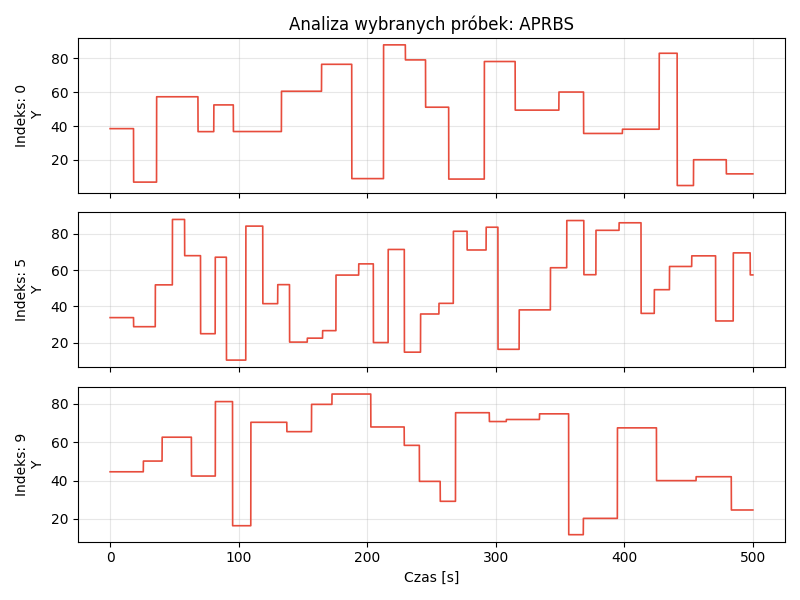

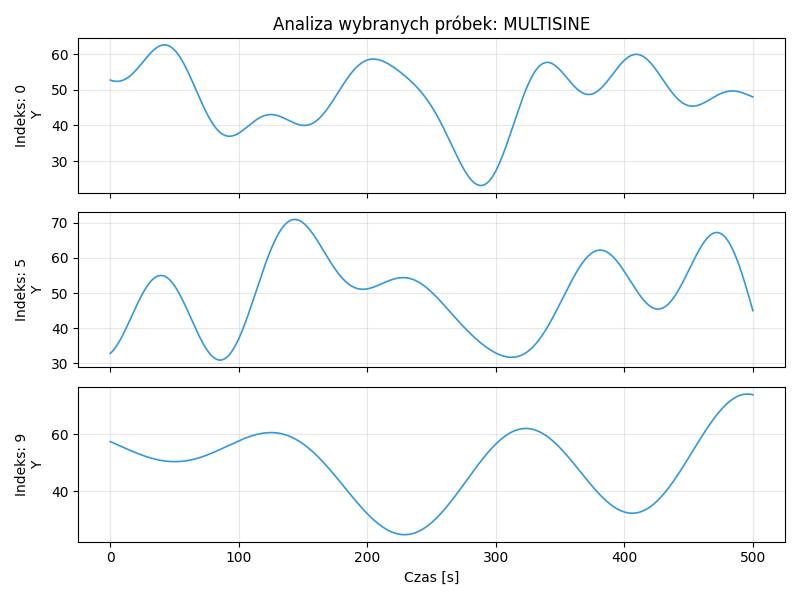

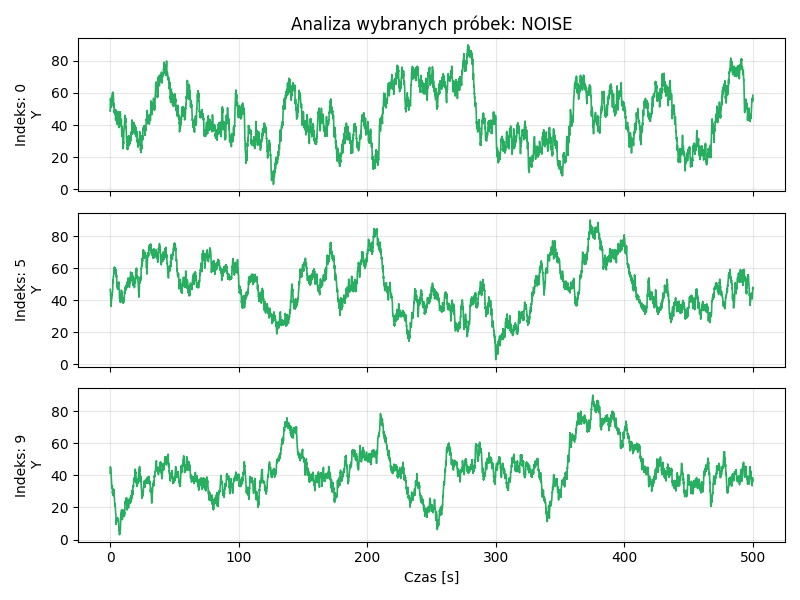

In [ ]:
creator = DatasetCreator(t_span=[0, 500], dt=0.1, amp_range=(3, 90), noise_level=0.0)
dataset = creator.create_dataset(n_aprbs=10, n_multisine=10, n_noise=10)

for category, signals in dataset.items():
    print(f"\n=== Kategoria: {category.upper()} ===")
    for i, traj in enumerate(signals[:1]):  
        print(f"Trajektoria nr {i+1}:")
        print(f"  t (pierwsze 5): {traj.t[:5]}")
        print(f"  y (pierwsze 5): {traj.y[:5]}")
        print(f"  Długość wektora: {len(traj.y)} próbek")
        print("-" * 30)

Plotter.plot_indices(dataset['aprbs'], "aprbs", indices=[0, 5, 9])

Plotter.plot_indices(dataset['multisine'], "multisine", indices=[0, 5, 9])

Plotter.plot_indices(dataset['noise'], "noise", indices=[0, 5, 9])

## FOURIER (DYSKRETNY)

--- Start generowania zestawu danych (Noise Level: 0.0) ---


Generowanie NOISE: 100%|██████████| 10/10 [00:00<00:00, 145.23it/s]


--- Generowanie zakończone ---
Kategoria APRBS: 10 sygnałów
Kategoria MULTISINE: 10 sygnałów
Kategoria NOISE: 10 sygnałów


Omega  (pierwsze 5): [29661.478584     +0.j          -506.11439539  -43.37921706j
   451.75967404+1333.98212543j  -176.37670889+1283.6925717j
  -709.39824708 +415.19199386j]


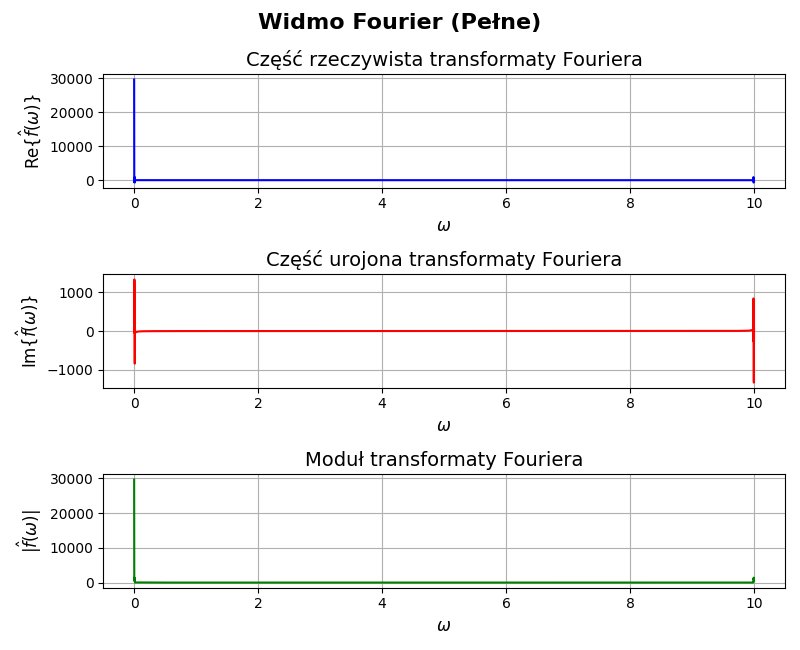

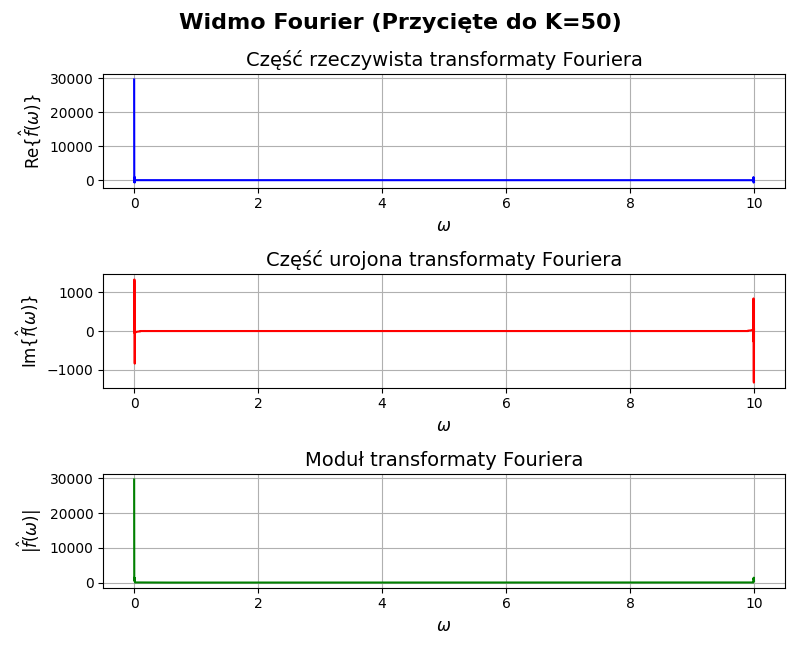

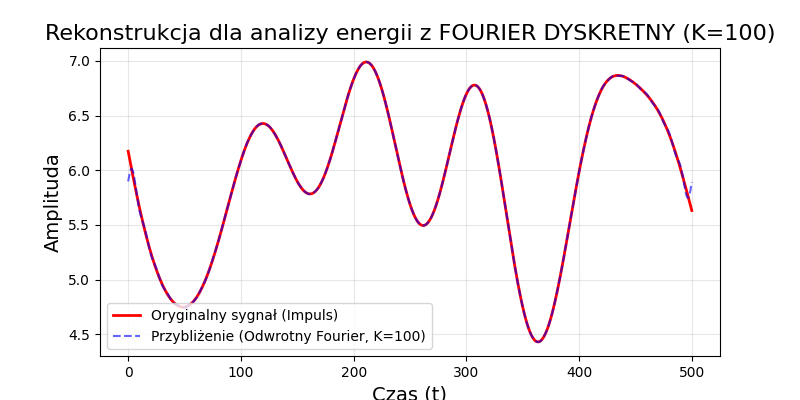

In [ ]:
creator = DatasetCreator(t_span=[0, 500], dt=0.1, amp_range=(3, 9), noise_level=0.0)
dataset = creator.create_dataset(n_aprbs=10, n_multisine=10, n_noise=10)

# sample_signal = dataset['aprbs'][0]  
sample_signal = dataset['multisine'][0]  

fourier_engine = DiscreteFourier(sample_signal.t, sample_signal.y)

k=100  # Liczba współczynników do zachowania 

omega_vec, f_omega_vec = fourier_engine.transform()
print(f"Omega  (pierwsze 5): {f_omega_vec[:5]}")

f_trimmed = fourier_engine.trim_spectrum(f_omega_vec=f_omega_vec, k=k)

y_reconstructed = fourier_engine.inverse_transform(f_trimmed)

Plotter.plot_fourier_transform(omega_vec, f_omega_vec, title="Widmo Fourier (Pełne)")
Plotter.plot_fourier_transform(omega_vec, f_trimmed, title="Widmo Fourier (Przycięte do K=50)")

# Oryginał vs Rekonstrukcja
Plotter.plot_fourier_comparison(
    sample_signal.t, 
    sample_signal.y, 
    y_reconstructed, 
    K=k,
    title=f"Rekonstrukcja dla analizy energii z FOURIER DYSKRETNY (K={k})"
)


## FOURIER (NOWY)

--- Start generowania zestawu danych (Noise Level: 0.0) ---


Generowanie NOISE: 100%|██████████| 10/10 [00:00<00:00, 328.44it/s]


--- Generowanie zakończone ---
Kategoria APRBS: 10 sygnałów
Kategoria MULTISINE: 10 sygnałów
Kategoria NOISE: 10 sygnałów
--- Transformaty dla omega w zakresie [-5.0, 5.0] ---


Omega  (pierwsze 5): [-1.20203873+0.69909272j  0.09119441-0.12504341j  1.25685251+0.88032438j
  0.63001309+2.29027549j -0.90144488+2.09652924j]


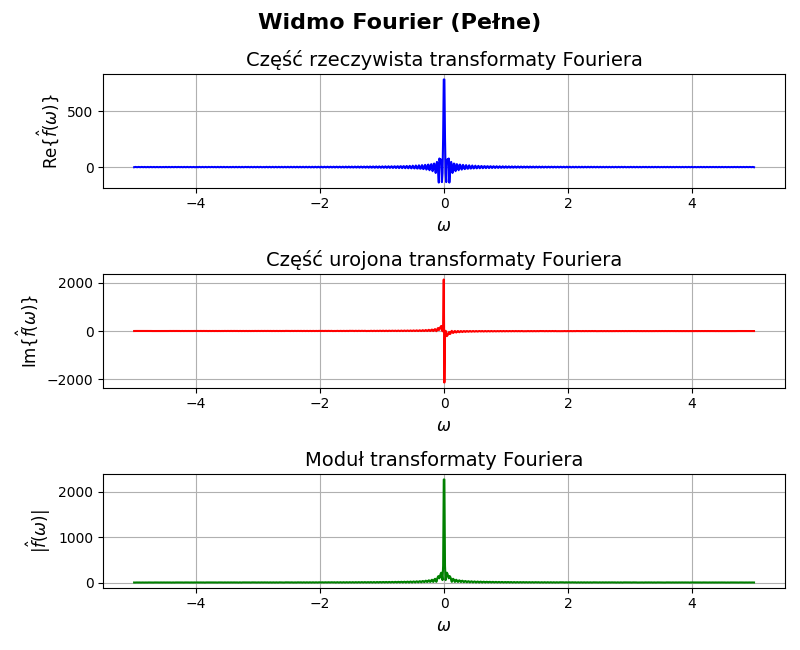

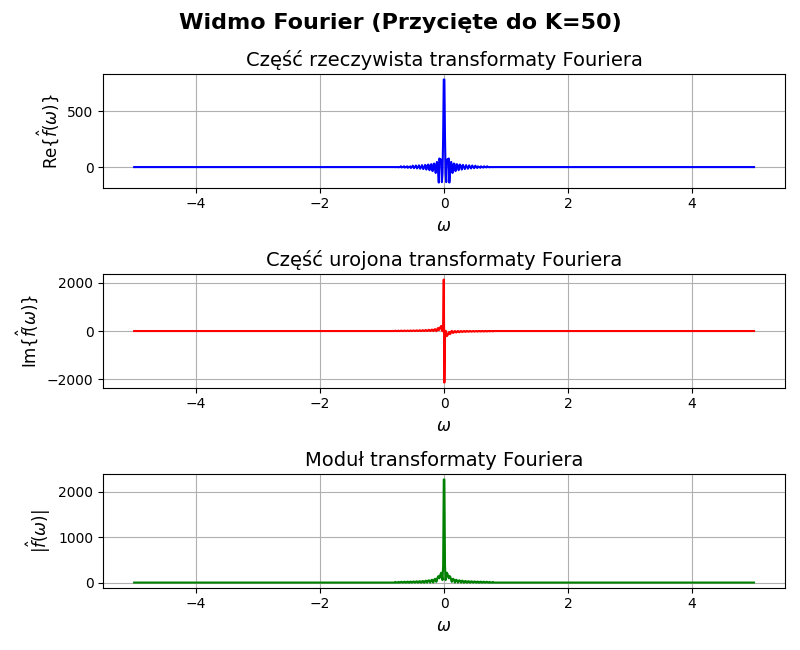

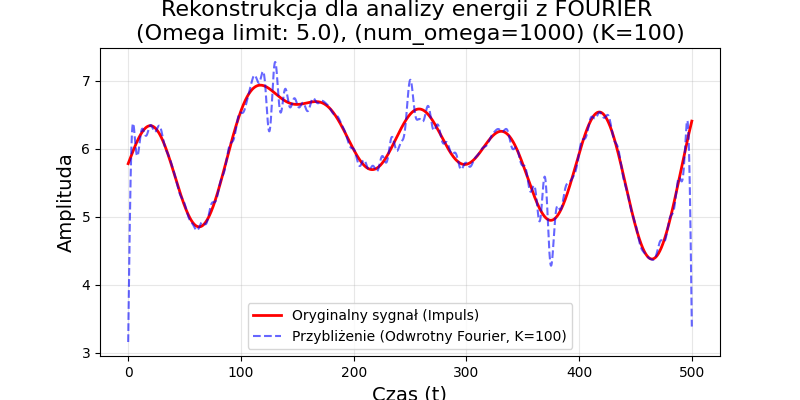

In [4]:
# 1. Generujemy dane
creator = DatasetCreator(t_span=[0, 500], dt=0.1, amp_range=(3, 9), noise_level=0.0)
dataset = creator.create_dataset(n_aprbs=10, n_multisine=10, n_noise=10)

# sample_signal = dataset['aprbs'][0]  # Pobieramy pierwszy sygnał z kategorii APRBS
sample_signal = dataset['multisine'][0]  # Pobieramy pierwszy sygnał z kategorii MULTISINE


# 2. Inicjalizacja klasy Fourier
fourier_engine = Fourier(sample_signal.t, sample_signal.y)

# Parametry analizy
omega_limit = 5.0  # Zakres częstotliwości do analizy
num_omega = 1000  # Liczba punktów w zakresie omega - Używamy mniejszego num_omega dla szybkości lub większego dla precyzji
k=100  # Liczba współczynników do zachowania (przycinanie)

print(f"--- Transformaty dla omega w zakresie [-{omega_limit}, {omega_limit}] ---")

# 3. Obliczenie transformaty prostej dla zakresu częstotliwości
omega_vec, f_omega_vec = fourier_engine.transform(omega_limit=omega_limit, num_omega=num_omega)
print(f"Omega  (pierwsze 5): {f_omega_vec[:5]}")

# 4. Przycinamy do 50 najważniejszych współczynników (K=50)
f_trimmed = fourier_engine.trim_spectrum(omega_vec=omega_vec, f_omega_vec=f_omega_vec, k=k)

# 4. Obliczenie transformaty odwrotnej (rekonstrukcja sygnału)
y_reconstructed = fourier_engine.inverse_transform(omega_vec, f_trimmed)

# 5. Wizualizacja wyników
# Wykres widma (Część rzeczywista, urojona i moduł)
Plotter.plot_fourier_transform(omega_vec, f_omega_vec, title="Widmo Fourier (Pełne)")
Plotter.plot_fourier_transform(omega_vec, f_trimmed, title="Widmo Fourier (Przycięte do K=50)")

# Wykres porównawczy (Oryginał vs Rekonstrukcja)
Plotter.plot_fourier_comparison(
    sample_signal.t, 
    sample_signal.y, 
    y_reconstructed, 
    K=k,
    title=f"Rekonstrukcja dla analizy energii z FOURIER \n(Omega limit: {omega_limit}), (num_omega={num_omega}) (K={k})"
)


## FOURIER (STARY)

--- Start generowania zestawu danych (Noise Level: 0.0) ---


Generowanie NOISE: 100%|██████████| 10/10 [00:00<00:00, 280.55it/s]


--- Generowanie zakończone ---
Kategoria APRBS: 10 sygnałów
Kategoria MULTISINE: 10 sygnałów
Kategoria NOISE: 10 sygnałów


--- Transformaty dla omega w zakresie [-5.0, 5.0] ---
Omega  (pierwsze 5): [-6.61526227 +6.66429887j  6.93021665 +7.54744711j
 -4.82043593+14.48283931j  1.08965363 +2.18205512j
  3.09539631+15.80820122j]


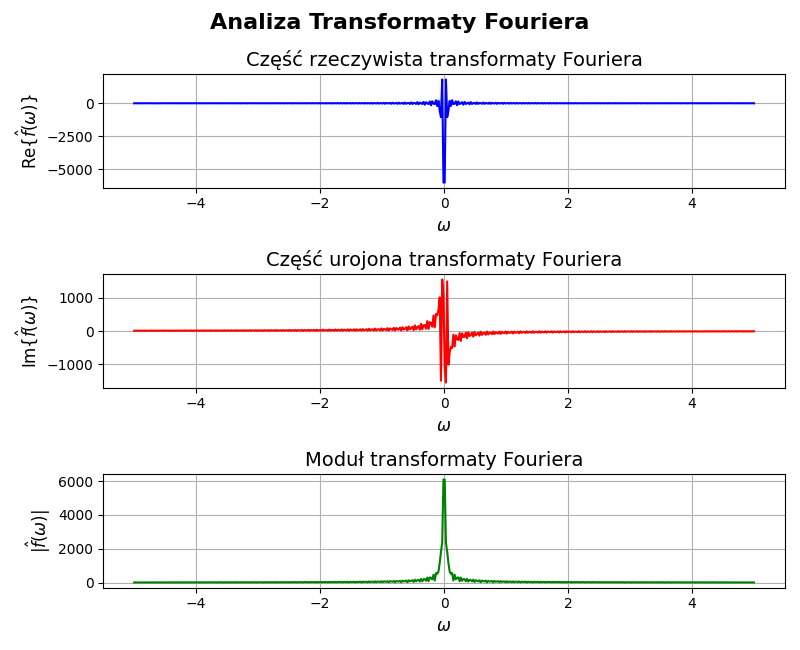

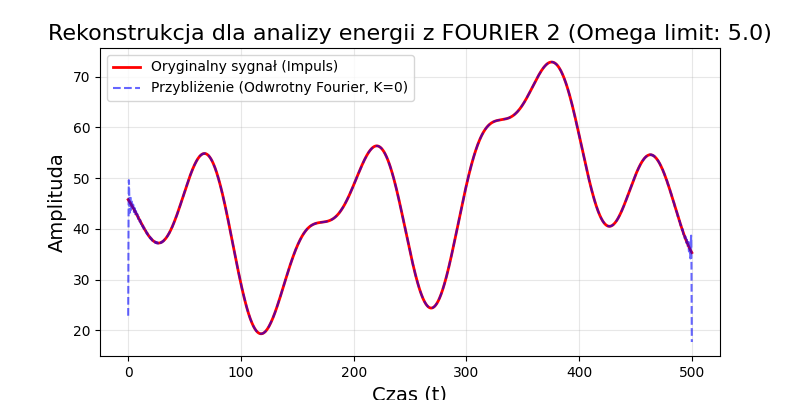

In [5]:
# 1. Generujemy dane
creator = DatasetCreator(t_span=[0, 500], dt=0.1, amp_range=(3, 90), noise_level=0.0)
dataset = creator.create_dataset(n_aprbs=10, n_multisine=10, n_noise=10)

sample_signal = dataset['multisine'][0]  # Pobieramy pierwszy sygnał z kategorii MULTISINE

# 2. Inicjalizacja klasy Fourier
fourier_engine = Fourier2(sample_signal.t, sample_signal.y)

# 3. Obliczenie transformaty prostej dla zakresu częstotliwości
omega_limit = 5.0  # Zakres częstotliwości do analizy
omega_vec = np.linspace(-omega_limit, omega_limit, 500)
f_omega = fourier_engine.transform(omega_vec)

print(f"--- Transformaty dla omega w zakresie [-{omega_limit}, {omega_limit}] ---")
print(f"Omega  (pierwsze 5): {f_omega[:5]}")

# 4. Obliczenie transformaty odwrotnej (rekonstrukcja sygnału)
# Używamy mniejszego num_omega dla szybkości lub większego dla precyzji
y_reconstructed = fourier_engine.inverse_transform(
    omega_limit=omega_limit, 
    num_omega=1000
)

# 5. Wizualizacja wyników
# Wykres widma (Część rzeczywista, urojona i moduł)
Plotter.plot_fourier_transform(omega_vec, f_omega)

# Wykres porównawczy (Oryginał vs Rekonstrukcja)
Plotter.plot_fourier_comparison(
    sample_signal.t, 
    sample_signal.y, 
    y_reconstructed, 
    K=0,
    title=f"Rekonstrukcja dla analizy energii z FOURIER 2 (Omega limit: {omega_limit})"
)


## ANALIZA ENERGII

--- Start generowania zestawu danych (Noise Level: 0.0) ---


Generowanie APRBS: 100%|██████████| 10/10 [00:00<00:00, 2106.31it/s]


Generowanie NOISE: 100%|██████████| 10/10 [00:00<00:00, 276.86it/s]


--- Generowanie zakończone ---
Kategoria APRBS: 10 sygnałów
Kategoria MULTISINE: 10 sygnałów
Kategoria NOISE: 10 sygnałów

--- ANALIZA SYGNAŁU MULTISINE - NUMPY FFT ---
Energia w dziedzinie czasu: 12213416.08
Wspołczynniki FFT - liczba: 2501...
Wspołczynniki FFT: [243778.58151536    +0.j            847.93312704 +3847.52945701j
  -5221.74760148-12022.05223347j  -2687.18170664+18195.70417721j
  -6943.08917095 -1607.92314499j]...
Energia w dziedzinie częstotliwości: 12049507.72
Liczba współczynników (K) dla 99.9% energii: 6


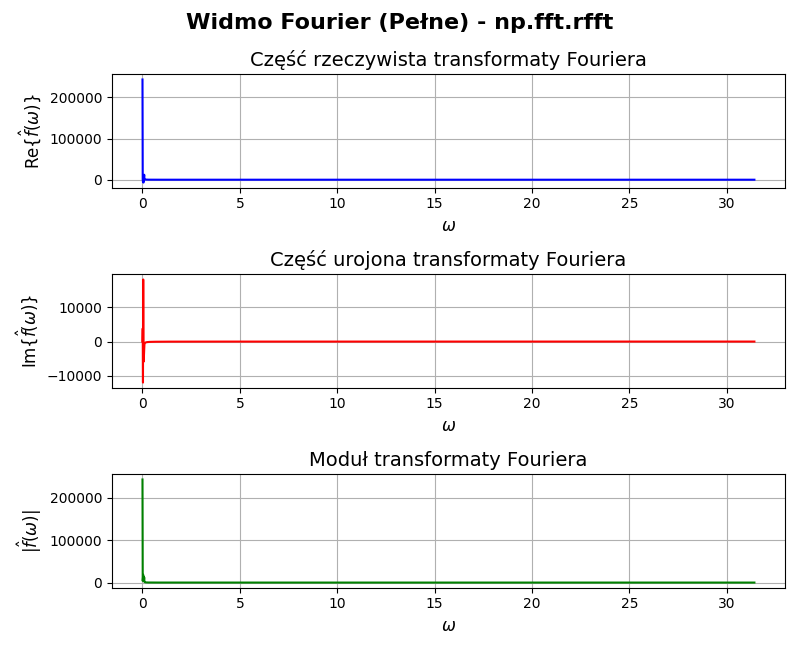

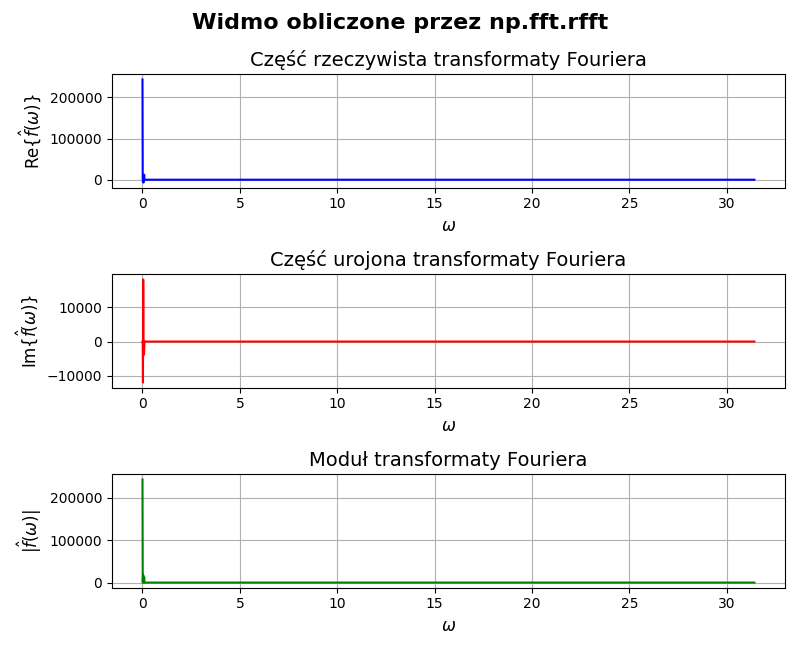

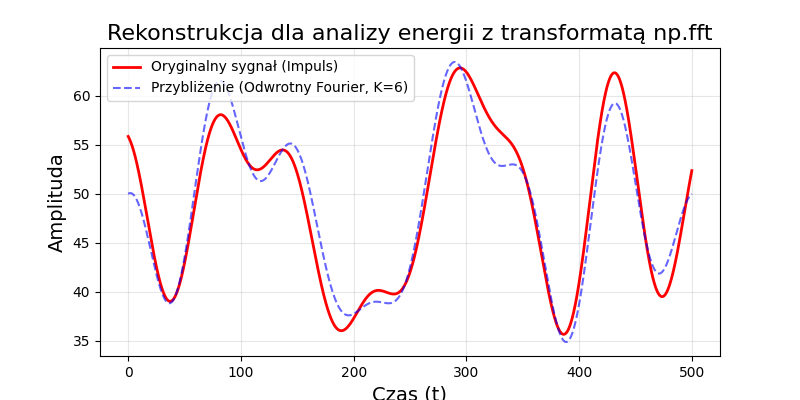


--- ANALIZA SYGNAŁU MULTISINE - WŁASNA FFT ---
Energia w dziedzinie czasu: 12213416.08
Wspołczynniki FFT - liczba: 2501...
Wspołczynniki FFT: [243778.58151536    +0.j            847.93312704 +3847.52945701j
  -5221.74760148-12022.05223347j  -2687.18170664+18195.70417721j
  -6943.08917095 -1607.92314499j]...
Energia w dziedzinie częstotliwości: 12213416.08
Liczba współczynników (K) dla 99.9% energii: 13


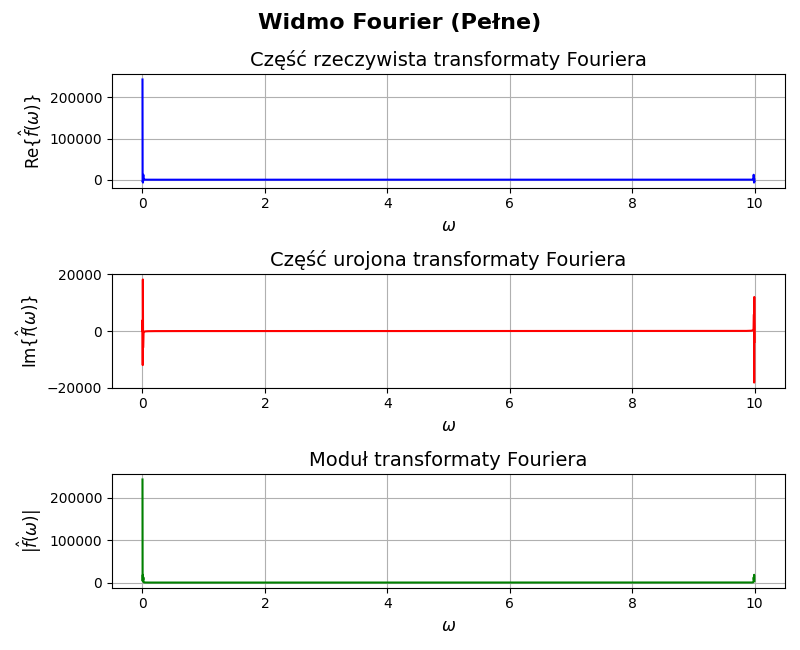

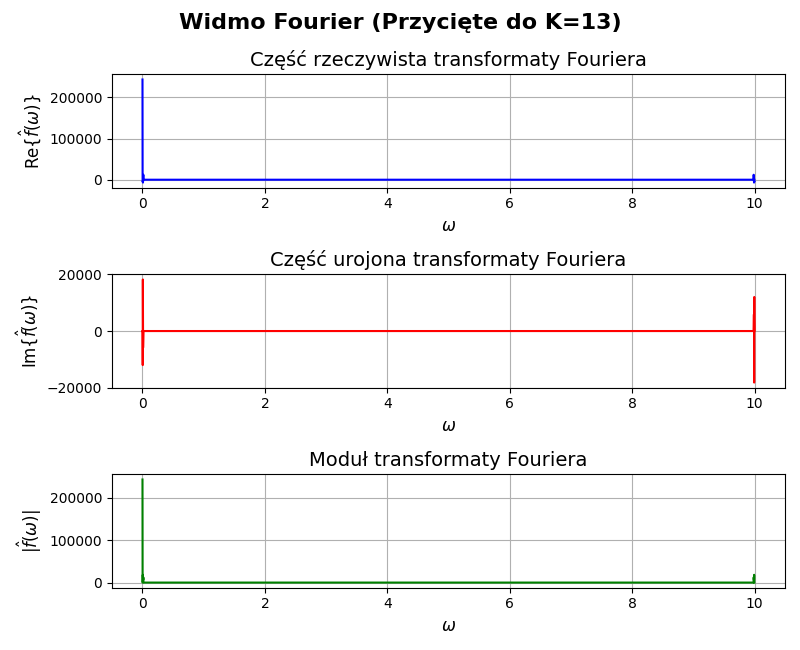

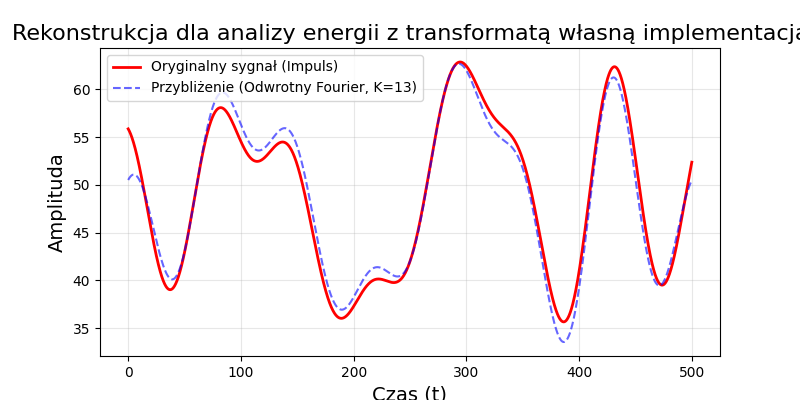

In [ ]:
creator = DatasetCreator(t_span=[0, 500], dt=0.1, amp_range=(3, 90), noise_level=0.0)
dataset = creator.create_dataset(n_aprbs=10, n_multisine=10, n_noise=10)

energy_threshold = 0.999  # Procent energii do zachowania (np. 0.999 dla 99.9%)

# Analiza energii dla NUMPY FFT
print("\n--- ANALIZA SYGNAŁU MULTISINE - NUMPY FFT ---")# Pobieramy pierwszy sygnał z listy
signal = dataset['multisine'][0] 

e_time = EnergyAnalyzer.calculate_total_energy(signal)
print(f"Energia w dziedzinie czasu: {e_time:.2f}")

coeffs = np.fft.rfft(signal.y)
freqs = np.fft.rfftfreq(len(signal.y), d=(signal.t[1] - signal.t[0]))
omega_numpy = 2 * np.pi * freqs

results = EnergyAnalyzer.analyze_energy_distribution(coeffs, N=len(signal.y), threshold=energy_threshold)
print(f"Wspołczynniki FFT - liczba: {len(coeffs)}...")  # Pokazujemy tylko pierwsze 5 współczynników
print(f"Wspołczynniki FFT: {coeffs[:5]}...")  # Pokazujemy tylko pierwsze 5 współczynników
print(f"Energia w dziedzinie częstotliwości: {results['total_energy_freq']:.2f}")
print(f"Liczba współczynników (K) dla {energy_threshold*100}% energii: {results['k_threshold']}")

magnitudes = np.abs(coeffs)
threshold_val = np.sort(magnitudes)[-results['k_threshold']]
coeffs_trimmed = np.where(magnitudes >= threshold_val, coeffs, 0)

y_reconstructed_np = np.fft.irfft(coeffs_trimmed, n=len(signal.y))

Plotter.plot_fourier_transform(omega_numpy, coeffs, title="Widmo Fourier (Pełne) - np.fft.rfft")
Plotter.plot_fourier_transform(omega_numpy, coeffs_trimmed, title="Widmo obliczone przez np.fft.rfft")

Plotter.plot_fourier_comparison(
    signal.t, 
    signal.y, 
    y_reconstructed_np, 
    K=results['k_threshold'],
    title=f"Rekonstrukcja dla analizy energii z transformatą np.fft"
)

# Analiza energii dla WŁASNEGO FFT
print("\n--- ANALIZA SYGNAŁU MULTISINE - WŁASNA FFT ---")# Pobieramy pierwszy sygnał z listy
signal = dataset['multisine'][0] 

e_time = EnergyAnalyzer.calculate_total_energy(signal)
print(f"Energia w dziedzinie czasu: {e_time:.2f}")

fourier_engine = DiscreteFourier(signal.t, signal.y)
frq, cfs = fourier_engine.transform()

results_dsc = EnergyAnalyzer.analyze_energy_distribution(cfs, N=len(signal.y), threshold=energy_threshold)
print(f"Wspołczynniki FFT - liczba: {len(coeffs)}...")  # Pokazujemy tylko pierwsze 5 współczynników
print(f"Wspołczynniki FFT: {coeffs[:5]}...")  # Pokazujemy tylko pierwsze 5 współczynników
print(f"Energia w dziedzinie częstotliwości: {results_dsc['total_energy_freq']:.2f}")
print(f"Liczba współczynników (K) dla {energy_threshold*100}% energii: {results_dsc['k_threshold']}")

omega_vec, f_omega_vec = fourier_engine.transform()

f_trimmed = fourier_engine.trim_spectrum(f_omega_vec=f_omega_vec, k=results_dsc['k_threshold'])

y_reconstructed = fourier_engine.inverse_transform(f_trimmed)

Plotter.plot_fourier_transform(omega_vec, f_omega_vec, title="Widmo Fourier (Pełne)")
Plotter.plot_fourier_transform(omega_vec, f_trimmed, title=f"Widmo Fourier (Przycięte do K={results_dsc['k_threshold']})")

Plotter.plot_fourier_comparison(
    signal.t, 
    signal.y, 
    y_reconstructed, 
    K=results_dsc['k_threshold'],
    title=f"Rekonstrukcja dla analizy energii z transformatą własną implementacją"
)

## ANALIZA DOKŁADNOŚCI

--- Start generowania zestawu danych (Noise Level: 0.0) ---


Generowanie NOISE: 100%|██████████| 10/10 [00:00<00:00, 275.83it/s]


--- Generowanie zakończone ---
Kategoria APRBS: 10 sygnałów
Kategoria MULTISINE: 10 sygnałów
Kategoria NOISE: 10 sygnałów

--- ANALIZA SYGNAŁU MULTISINE ---
Aby błąd maksymalny był < 2.0, potrzeba K = 12


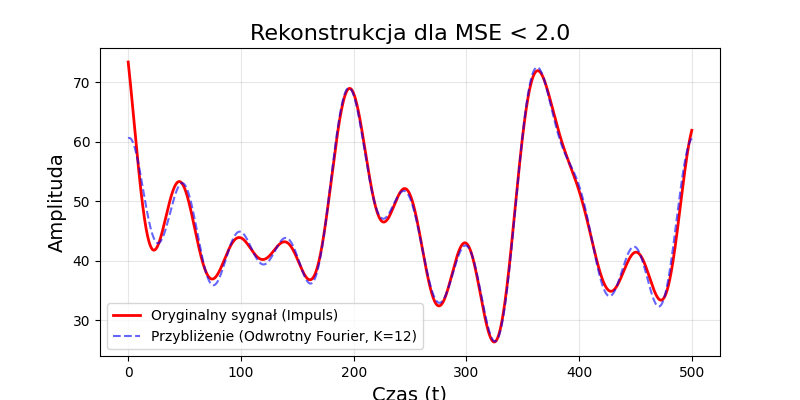

In [ ]:
creator = DatasetCreator(t_span=[0, 500], dt=0.1, amp_range=(3, 90), noise_level=0.0)
dataset = creator.create_dataset(n_aprbs=10, n_multisine=10, n_noise=10)

print("\n--- ANALIZA SYGNAŁU MULTISINE ---")
signal = dataset['multisine'][0] 

coeffs = np.fft.rfft(signal.y)

max_allowed_diff = 2.0 
mode = 'mse'  #'max_error' jeśli  maksymalny błąd zamiast MSE
results = FidelityAnalyzer.analyze_by_error(signal.y, coeffs, threshold=max_allowed_diff, mode=mode)

print(f"Aby błąd maksymalny był < {max_allowed_diff}, potrzeba K = {results['k_threshold']}")

Plotter.plot_fourier_comparison(
    signal.t, 
    signal.y, 
    results['reconstructed_y'], 
    K=results['k_threshold'],
    title=f"Rekonstrukcja dla {mode.upper()} < {max_allowed_diff}"
)

## TESTY

--- Start generowania zestawu danych (Noise Level: 0.0) ---


Generowanie NOISE: 100%|██████████| 100/100 [00:00<00:00, 313.47it/s]



--- Generowanie zakończone ---
Kategoria APRBS: 100 sygnałów
Kategoria MULTISINE: 100 sygnałów
Kategoria NOISE: 100 sygnałów
Przetwarzanie kategorii: APRBS...
aprbs, 0
aprbs, 1
aprbs, 2
aprbs, 3
aprbs, 4
aprbs, 5
aprbs, 6
aprbs, 7
aprbs, 8
aprbs, 9
aprbs, 10
aprbs, 11
aprbs, 12
aprbs, 13
aprbs, 14
aprbs, 15
aprbs, 16
aprbs, 17
aprbs, 18
aprbs, 19
aprbs, 20
aprbs, 21
aprbs, 22
aprbs, 23
aprbs, 24
aprbs, 25
aprbs, 26
aprbs, 27
aprbs, 28
aprbs, 29
aprbs, 30
aprbs, 31
aprbs, 32
aprbs, 33
aprbs, 34
aprbs, 35
aprbs, 36
aprbs, 37
aprbs, 38
aprbs, 39
aprbs, 40
aprbs, 41
aprbs, 42
aprbs, 43
aprbs, 44
aprbs, 45
aprbs, 46
aprbs, 47
aprbs, 48
aprbs, 49
aprbs, 50
aprbs, 51
aprbs, 52
aprbs, 53
aprbs, 54
aprbs, 55
aprbs, 56
aprbs, 57
aprbs, 58
aprbs, 59
aprbs, 60
aprbs, 61
aprbs, 62
aprbs, 63
aprbs, 64
aprbs, 65
aprbs, 66
aprbs, 67
aprbs, 68
aprbs, 69
aprbs, 70
aprbs, 71
aprbs, 72
aprbs, 73
aprbs, 74
aprbs, 75
aprbs, 76
aprbs, 77
aprbs, 78
aprbs, 79
aprbs, 80
aprbs, 81
aprbs, 82
aprbs, 83
aprbs, 84


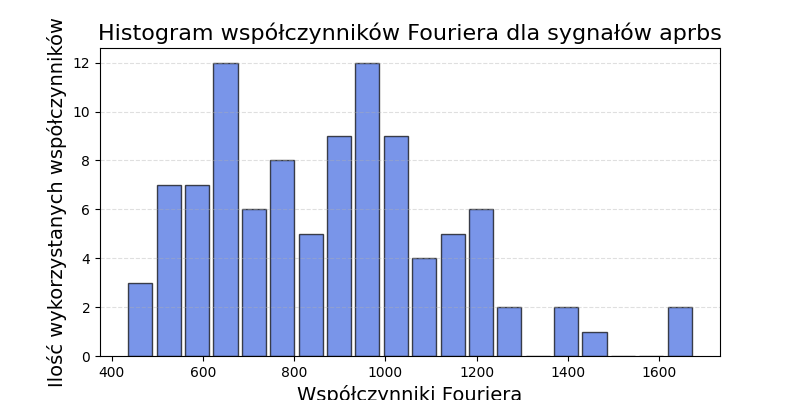

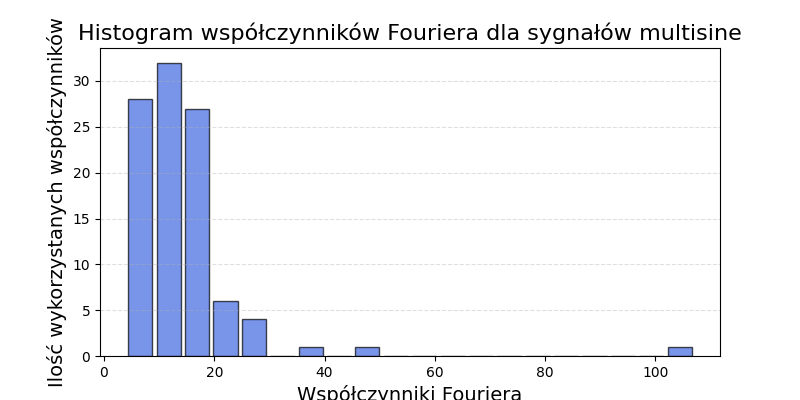

c:\Users\janga\OneDrive\Pulpit\Szkoła\miis\Signals_1D_compression\Plotter.py:173: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(8, 4))


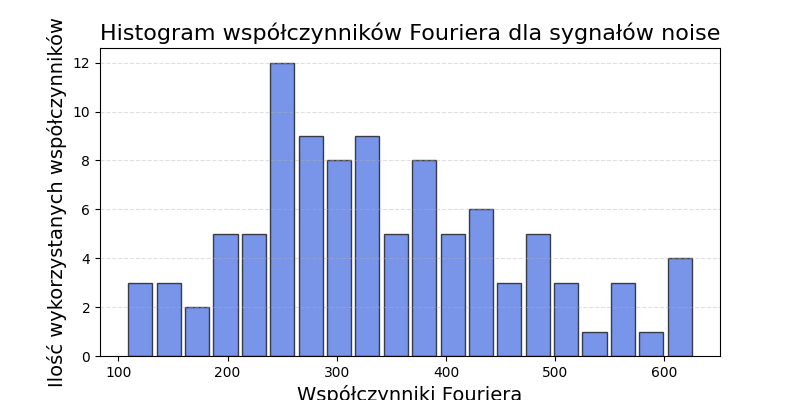

            category  mean_k       std_k min_k max_k count
aprbs          aprbs  877.54  263.217986   431  1677   100
multisine  multisine   14.59    11.47963     4   107   100
noise          noise  340.63  122.246853   107   627   100


In [ ]:
creator = DatasetCreator(t_span=[0, 500], dt=0.1, amp_range=(3, 90), noise_level=0.0)
big_dataset = creator.create_dataset(n_aprbs=100, n_multisine=100, n_noise=100)

tester = FidelityTester(big_dataset)

# Testy z naszą transformatą są długie (około 10 min)
stats = tester.run(threshold=3.0, mode='max', use_custom_fft=True)

print("--- RAPORT KOSZTU REPREZENTACJI (K) ---")
print(tester.display_results())

## OUTDATED

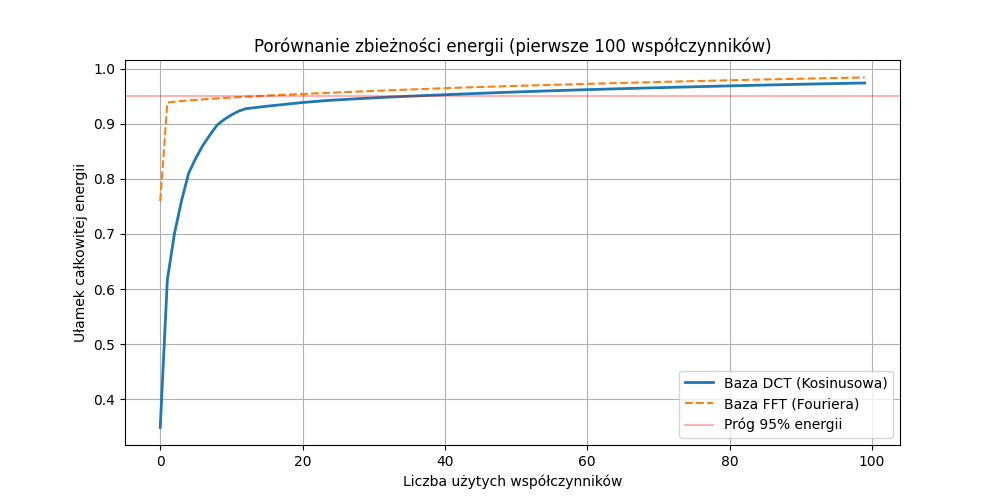

In [10]:
import numpy as np
import scipy.fftpack as fftpack
import matplotlib.pyplot as plt

# 1. Tworzymy sygnał testowy (suma sinusów - model prostego dźwięku)
N = 512
t = np.linspace(0, 1, N)
signal = np.sin(2 * np.pi * 5 * t) + 0.5 * np.sin(2 * np.pi * 20 * t) + 0.2 * np.random.randn(N)

# 2. Obliczamy współczynniki w dwóch bazach
# FFT (Fourier) - bierzemy moduł, bo FFT daje liczby zespolone
coef_fft = np.abs(np.fft.rfft(signal)) 
# DCT (Kosinusowa) - standard w audio
coef_dct = np.abs(fftpack.dct(signal, norm='ortho'))

# 3. Funkcja do obliczania skumulowanej energii (zbieżności)
def get_energy_convergence(coeffs):
    # Sortujemy współczynniki od największego (najważniejszego) do najmniejszego
    sorted_coeffs = np.sort(np.abs(coeffs))[::-1]
    # Liczymy sumę skumulowaną kwadratów (energia to kwadrat amplitudy)
    energy_cumulative = np.cumsum(sorted_coeffs**2)
    # Normalizujemy do 1.0 (czyli do 100%)
    return energy_cumulative / energy_cumulative[-1]

# 4. Obliczamy krzywe zbieżności
energy_fft = get_energy_convergence(coef_fft)
energy_dct = get_energy_convergence(coef_dct)

# 5. Wykres porównawczy
plt.figure(figsize=(10, 5))
plt.plot(energy_dct[:100], label='Baza DCT (Kosinusowa)', linewidth=2)
plt.plot(energy_fft[:100], label='Baza FFT (Fouriera)', linestyle='--')
plt.axhline(y=0.95, color='r', alpha=0.3, label='Próg 95% energii')
plt.title("Porównanie zbieżności energii (pierwsze 100 współczynników)")
plt.xlabel("Liczba użytych współczynników")
plt.ylabel("Ułamek całkowitej energii")
plt.legend()
plt.grid(True)
plt.show()